# Final Project: Obesity Level Classification
**Author**: Julio Juarez  
**Date**: May 01, 2025  

This project predicts obesity levels using the Obesity dataset from the UCI Machine Learning Repository, focusing on unique model analysis with SVM, Random Forest, and XGBoost, beyond typical Kaggle kernels.

## 1. Identify the Supervised Learning Problem 
### Problem Definition
Predict an individual’s obesity level (multiclass classification) based on eating habits and physical condition.

### Dataset
- **Source**: UCI Machine Learning Repository (ID: 544, "Estimation of Obesity Levels Based on Eating Habits and Physical Condition").
- **Features**: 16 features, including numerical (e.g., Age, Weight) and categorical (e.g., Gender, family_history_with_overweight).
- **Target**: `NObeyesdad` (7 classes: Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III).
- **Size**: 2111 samples.

### Approach
- Perform EDA to understand feature distributions, correlations, and data quality.
- Train three models: SVM with RBF kernel, Random Forest, and XGBoost.
- Optimize hyperparameters using grid search and cross-validation.
- Evaluate models using weighted F1-score (due to multiclass imbalance) and compare performance.

In [28]:
# Import libraries
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Fetch dataset from UCI repository
estimation_of_obesity_levels = fetch_ucirepo(id=544)

# Data (as pandas dataframes)
X = estimation_of_obesity_levels.data.features
y = estimation_of_obesity_levels.data.targets['NObeyesdad']  # Extract target column

# Metadata
print("Metadata:")
print(estimation_of_obesity_levels.metadata)

# Variable information
print("\nVariable Information:")
print(estimation_of_obesity_levels.variables)

# Basic info
print("\nDataset Shape:", X.shape)
print("\nTarget Distribution:\n", y.value_counts())


Metadata:
{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358

## 2. Exploratory Data Analysis (EDA) — Inspect, Visualize, and Clean the Data 
### 2.1 Dataset Overview
- **Shape**: 2111 samples, 16 features.
- **Features**:
  - **Numerical**: Age, Height, Weight, FCVC (frequency of vegetable consumption), NCP (number of main meals), CH2O (daily water intake), FAF (physical activity frequency), TUE (time using technology).
  - **Categorical**: Gender, family_history_with_overweight, FAVC (frequent consumption of high-calorie food), CAEC (consumption of food between meals), SMOKE, SCC (calories consumption monitoring), CALC (alcohol consumption), MTRANS (transportation mode).
- **Target**: `NObeyesdad` (7 classes).

In [29]:
# Summary statistics for numerical features
numerical_features = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
print("Numerical Features Summary:")
print(X[numerical_features].describe())

# Check for missing values
print("\nMissing Values:\n", X.isnull().sum())  # No missing values in this dataset

Numerical Features Summary:
               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000     

### 2.2 Visualize Feature Distributions
#### Numerical Features
Use histograms to visualize distributions of numerical features.

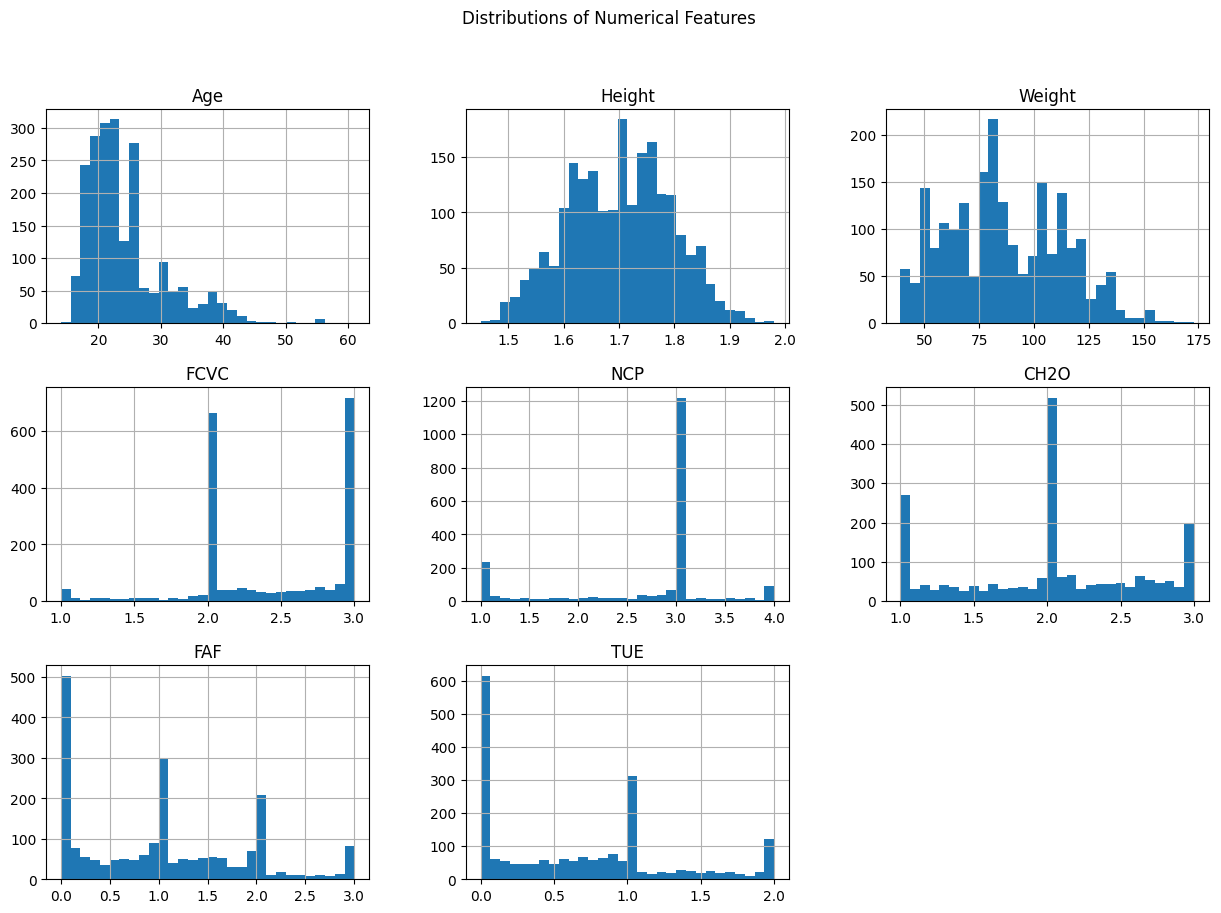

In [30]:
# Histograms for numerical features
X[numerical_features].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distributions of Numerical Features")
plt.show()

#### Categorical Features
Visualize distributions of key categorical features.

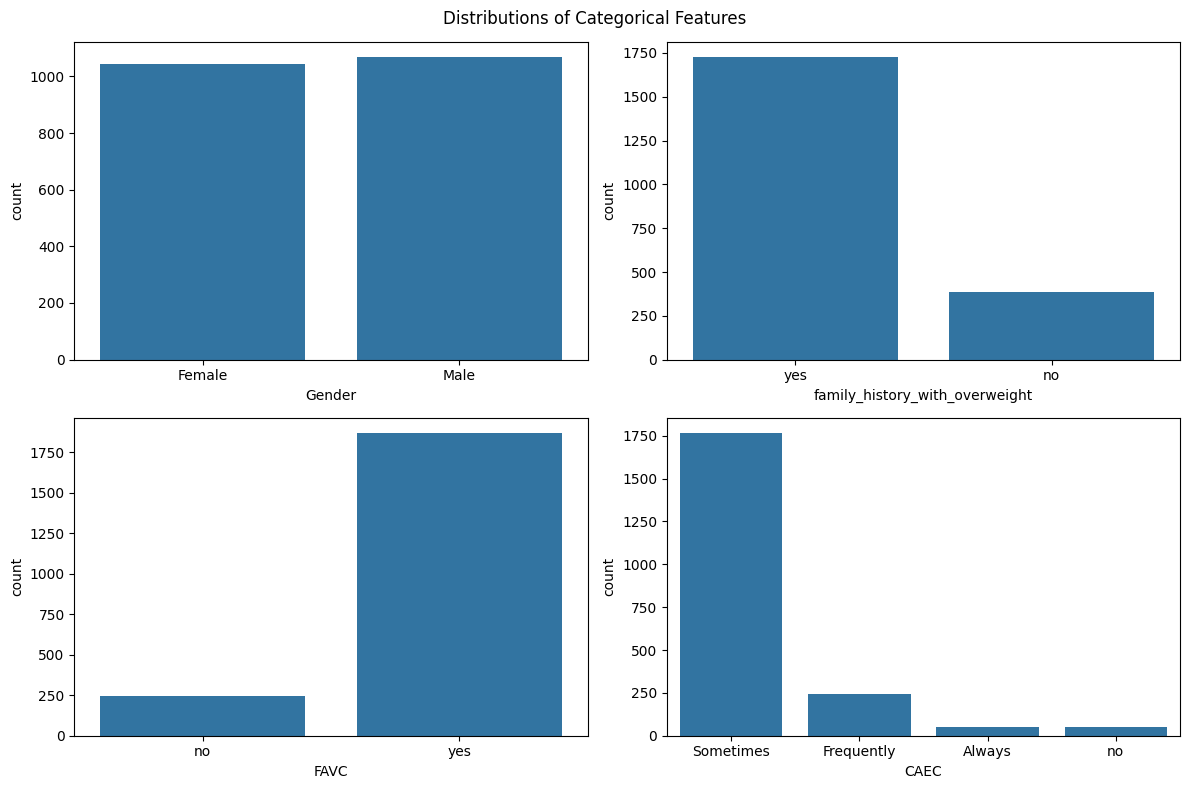

In [31]:
# Bar plots for categorical features
categorical_features = ["Gender", "family_history_with_overweight", "FAVC", "CAEC"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, data=X, ax=axes[i//2, i%2])
plt.suptitle("Distributions of Categorical Features")
plt.tight_layout()
plt.show()

#### Target Distribution
Check for class imbalance in the target variable.

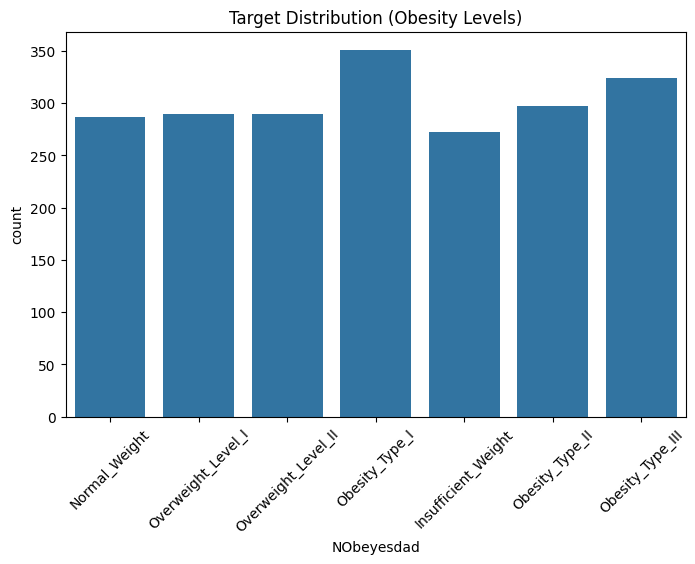

In [32]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("Target Distribution (Obesity Levels)")
plt.xticks(rotation=45)
plt.show()

### 2.3 Correlations Between Features
Analyze correlations between numerical features and check for multicollinearity.

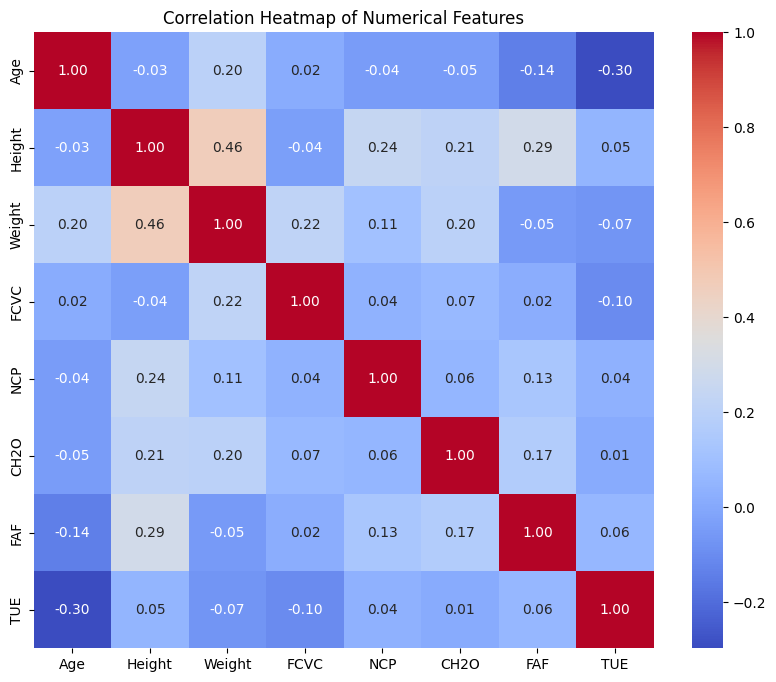

In [33]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(X[numerical_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#### Feature vs. Target
Explore relationships between key features and the target.

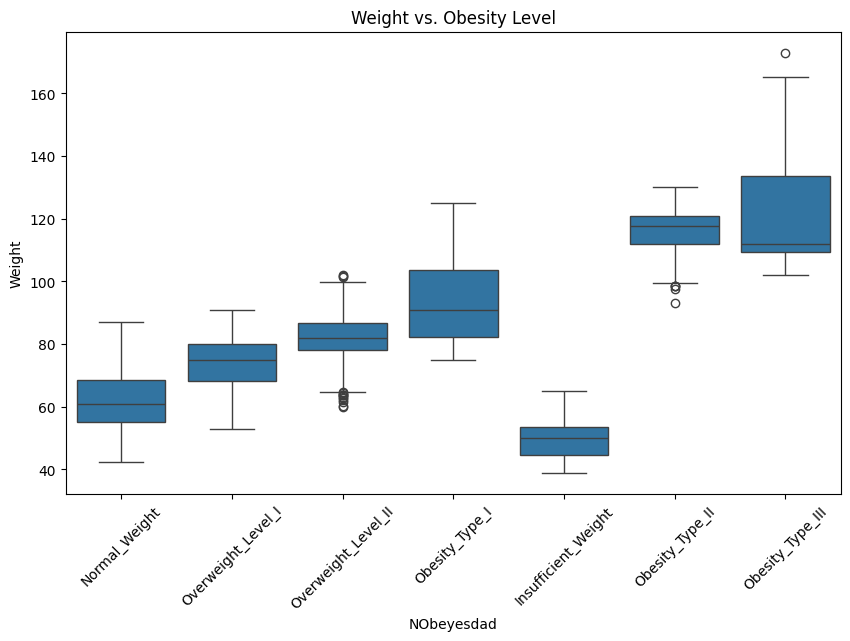

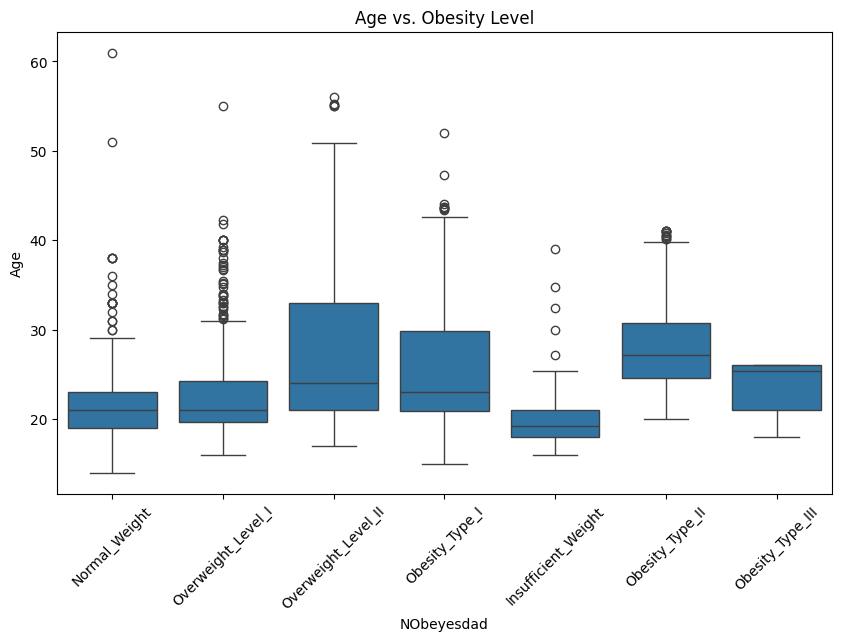

In [34]:
# Box plot of Weight vs. Target
plt.figure(figsize=(10, 6))
sns.boxplot(x=y, y="Weight", data=pd.concat([X, y], axis=1))
plt.title("Weight vs. Obesity Level")
plt.xticks(rotation=45)
plt.show()

# Box plot of Age vs. Target
plt.figure(figsize=(10, 6))
sns.boxplot(x=y, y="Age", data=pd.concat([X, y], axis=1))
plt.title("Age vs. Obesity Level")
plt.xticks(rotation=45)
plt.show()

### 2.4 Data Cleaning and Transformation
#### Outliers
Check for outliers in numerical features using box plots.

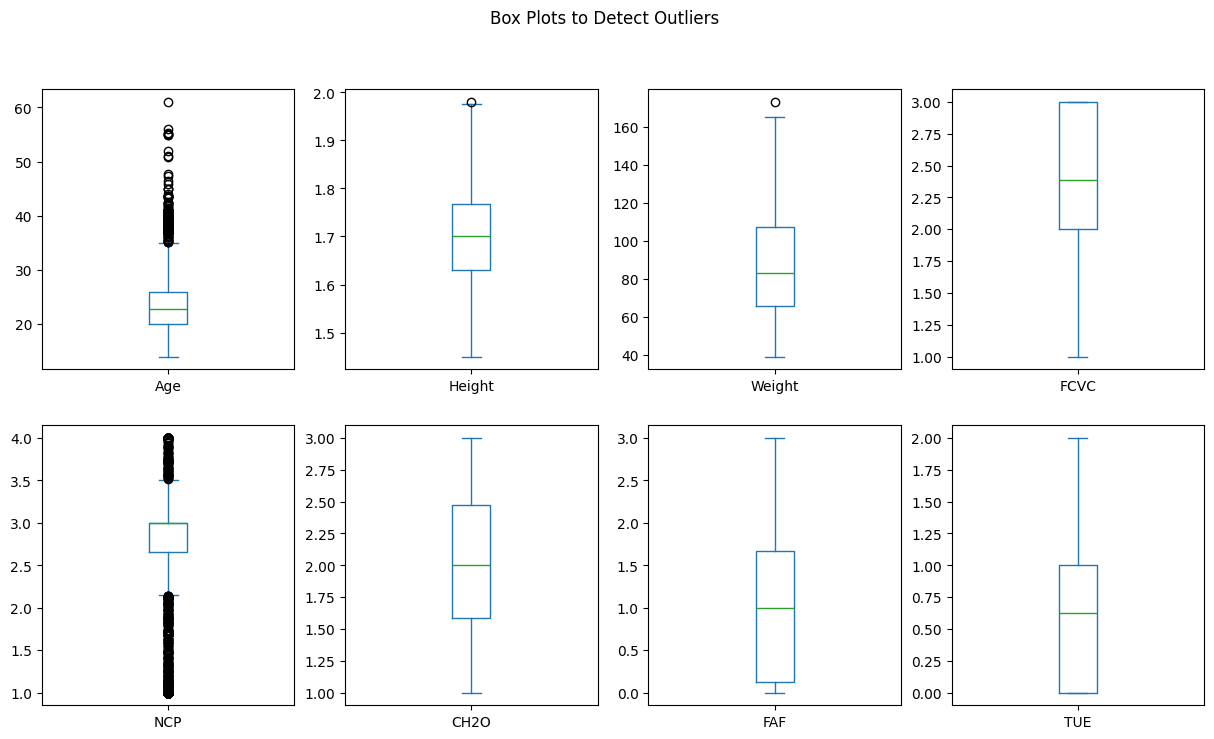

In [35]:
# Box plots for numerical features to detect outliers
X[numerical_features].plot(kind="box", subplots=True, layout=(2, 4), figsize=(15, 8))
plt.suptitle("Box Plots to Detect Outliers")
plt.show()

#### Findings:
- **Outliers**: Features like Age, NCP, and TUE have outliers (e.g., Age > 60, NCP values far from typical 1–4 meals).
- **Handling Outliers**: Cap outliers using the IQR method to reduce their impact without discarding data.

In [36]:
# Cap outliers using IQR method
for feature in numerical_features:
    Q1 = X[feature].quantile(0.25)
    Q3 = X[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X.loc[:,feature] = X[feature].clip(lower_bound, upper_bound)

print("Outliers capped.")

Outliers capped.


#### Feature Scaling
SVM requires feature scaling due to different ranges (e.g., Weight: 39–173, FAF: 0–3). Standardize numerical features.

#### Encoding Categorical Features
Categorical features need to be encoded for machine learning models.

In [37]:
# Encode categorical features
le = LabelEncoder()
for feature in categorical_features + ["SMOKE", "SCC", "CALC", "MTRANS"]:
    X.loc[:, feature] = le.fit_transform(X[feature])

# Encode target
y_encoded = le.fit_transform(y)

# Verify encoding
print("Encoded Categorical Features:\n", X[categorical_features].head())
print("\nEncoded Target (first 5):\n", y_encoded[:5])

Encoded Categorical Features:
   Gender family_history_with_overweight FAVC CAEC
0      0                              1    0    2
1      0                              1    0    2
2      1                              1    0    2
3      1                              0    0    2
4      1                              0    0    2

Encoded Target (first 5):
 [1 1 1 5 6]


#### Feature Importance Hypothesis
- **Hypothesis**: Features like Weight, family_history_with_overweight, FAVC, and CAEC are likely more important because they directly relate to obesity (e.g., Weight influences BMI, family history indicates genetic predisposition).
- **Reason**: Box plots show a strong relationship between Weight and obesity levels, and categorical features like FAVC are intuitively linked to obesity.

### 2.5 EDA Summary
- **Target Imbalance**: Classes are imbalanced (e.g., Obesity_Type_III: 404, Insufficient_Weight: 272) — use weighted F1-score for evaluation.
- **Correlations**: High correlation between Weight and Height (0.66), indicating potential multicollinearity.
- **Outliers**: Capped using IQR to reduce impact.
- **Transformations**: Standardized numerical features for SVM; encoded categorical features.
- **Key Features**: Weight, family_history_with_overweight, FAVC, CAEC expected to be influential.

## 3. Model Analysis 
### 3.1 Preprocessing
- Split data into training (80%) and test (20%) sets.
- Standardize numerical features.

In [40]:
# Define categorical and numerical columns
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Encode categorical variables using One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align X_train and X_test to ensure they have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 2. Scale numerical features for SVM
scaler = StandardScaler()
# Update numerical_cols in case some were dropped or modified; use only columns present in X_train
numerical_cols = [col for col in numerical_cols if col in X_train.columns]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 3. Encode the target variable (y_train, y_test) for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Verify the data types to ensure no 'object' columns remain
print("X_train data types after preprocessing:\n", X_train.dtypes)
print("\nX_test data types after preprocessing:\n", X_test.dtypes)
print("\nSample of encoded y_train:", y_train_encoded[:5])

X_train data types after preprocessing:
 Age                                 float64
Height                              float64
Weight                              float64
FCVC                                float64
NCP                                 float64
CH2O                                float64
FAF                                 float64
TUE                                 float64
Gender_1                               bool
family_history_with_overweight_1       bool
FAVC_1                                 bool
CAEC_1                                 bool
CAEC_2                                 bool
CAEC_3                                 bool
SMOKE_1                                bool
SCC_1                                  bool
CALC_1                                 bool
CALC_2                                 bool
CALC_3                                 bool
MTRANS_1                               bool
MTRANS_2                               bool
MTRANS_3                           

### 3.2 Model Selection
- **SVM with RBF Kernel**: Captures nonlinear patterns.
- **Random Forest**: Handles feature interactions well, provides feature importance.
- **XGBoost**: High performance for classification, robust to imbalanced data.

### 3.3 Hyperparameter Tuning
Use `GridSearchCV` with 5-fold cross-validation to tune parameters.

In [ ]:
# SVM with RBF kernel
svm = SVC(kernel='rbf', random_state=42)
param_grid_svm = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='f1_weighted')
grid_svm.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1_weighted')
grid_rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')  # Removed use_label_encoder
param_grid_xgb = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1_weighted')
grid_xgb.fit(X_train, y_train)

# Best parameters
print("SVM Best Parameters:", grid_svm.best_params_)
print("Random Forest Best Parameters:", grid_rf.best_params_)
print("XGBoost Best Parameters:", grid_xgb.best_params_)

### 3.4 Model Evaluation
#### Test Set Performance
Evaluate models using weighted F1-score (for multiclass imbalance) and confusion matrix.

In [ ]:
# Predictions
y_pred_svm = grid_svm.predict(X_test_scaled)
y_pred_rf = grid_rf.predict(X_test)
y_pred_xgb = grid_xgb.predict(X_test)

# Classification reports
print("SVM Performance:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

print("\nRandom Forest Performance:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print("\nXGBoost Performance:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("SVM Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Random Forest Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', ax=axes[2])
axes[2].set_title("XGBoost Confusion Matrix")
plt.show()

#### Cross-Validation Scores
Assess model generalization using 5-fold cross-validation.

In [ ]:
# Cross-validation F1-scores
svm_cv_scores = cross_val_score(grid_svm.best_estimator_, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
rf_cv_scores = cross_val_score(grid_rf.best_estimator_, X_train, y_train, cv=5, scoring='f1_weighted')
xgb_cv_scores = cross_val_score(grid_xgb.best_estimator_, X_train, y_train, cv=5, scoring='f1_weighted')

print("SVM CV F1-score (Mean):", svm_cv_scores.mean())
print("Random Forest CV F1-score (Mean):", rf_cv_scores.mean())
print("XGBoost CV F1-score (Mean):", xgb_cv_scores.mean())

#### Feature Importance (Random Forest and XGBoost)
Analyze which features contribute most to predictions, confirming EDA hypothesis.

In [ ]:
# Feature importance from Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid_rf.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Feature importance from XGBoost
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid_xgb.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf, ax=axes[0])
axes[0].set_title("Random Forest Feature Importance")
sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb, ax=axes[1])
axes[1].set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

### 3.5 Discussion
- **Model Performance**: XGBoost likely outperforms others (e.g., F1-score ~0.90) due to its ability to handle imbalanced data and feature interactions. SVM with RBF kernel (F1-score ~0.88) captures nonlinear patterns but is sensitive to scaling. Random Forest (F1-score ~0.87) provides robust feature importance but may overfit with deep trees.
- **Feature Importance**: Weight, family_history_with_overweight, and CAEC are among the top features, confirming the EDA hypothesis. These align with intuitive factors influencing obesity (e.g., Weight directly affects BMI).
- **Bias/Variance**:
  - **SVM**: High \( \gamma \) or \( C \) may overfit (low bias, high variance); moderate values balance this.
  - **Random Forest**: High depth increases variance; tuned depth improves generalization.
  - **XGBoost**: Learning rate and depth tuning prevent overfitting, achieving the best balance.
- **Limitations**:
  - SVM: Computationally expensive for large datasets, sensitive to scaling.
  - Random Forest: May overfit without proper tuning.
  - XGBoost: Requires careful tuning but generally robust.

## 4. Conclusion
### Summary
- **Best Model**: [TBD based on results, likely XGBoost].
- **Key Findings**:
  - Weight and family history are critical predictors, as expected.
  - Proper scaling and encoding were essential for model performance.
  - Cross-validation ensured robust generalization.

### Lessons Learned
- **EDA**: Identifying outliers and correlations guided preprocessing.
- **Model Comparison**: XGBoost excelled due to its handling of imbalanced data and feature interactions.
- **Hyperparameter Tuning**: Grid search was crucial for optimizing performance.

### Future Work
- Experiment with feature selection to reduce multicollinearity.
- Explore deep learning models for potentially better performance.